# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
# import Pkg; Pkg.add("Statistics")

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\fenya\OneDrive\BEE5850\BEE5850 Project\hw05-FenyaB`


In [3]:
# Pkg.add("GLM")

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [4]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Dates
using Optim
using GLM


## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

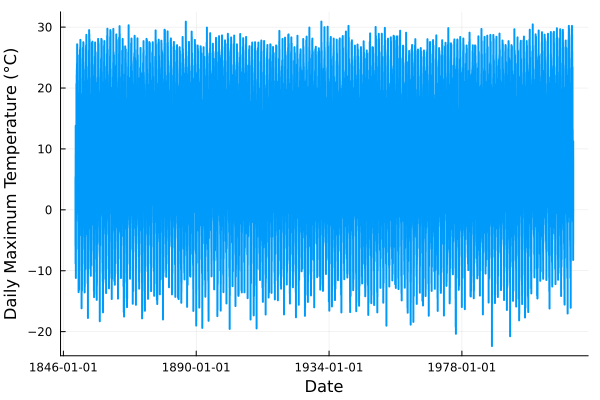

In [5]:
ithaca_dat = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
plot(ithaca_dat.Day, ithaca_dat.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?

# Solution

I first find and plot the annual maximum temperatures by adding a year column and grouping by this. I then fit the GEV model by minimizing the negative of the log likelihood. I compute the 99th quantile of this in order to get the 100-year return level. For the nonstationary GEV, I add another parameter to the model for the dependence of the location parameter on time ($\mu_1$). I calculate the AIC for both models using the equation from lecture.

In [59]:
max_dat = combine(ithaca_dat -> ithaca_dat[argmax(ithaca_dat.TempMax), :], groupby(transform(ithaca_dat, :Day => x->year.(x)), :Day_function))
rename!(max_dat, :Day_function => :Year)
select!(max_dat, [:Year, :TempMax])

Row,Year,TempMax
,Int64,Float64
1,1850,27.1789
2,1851,27.9148
3,1852,27.5242
4,1853,28.734
5,1854,29.5106
6,1855,27.6161
7,1856,27.4813
8,1857,28.0677
9,1858,28.0767


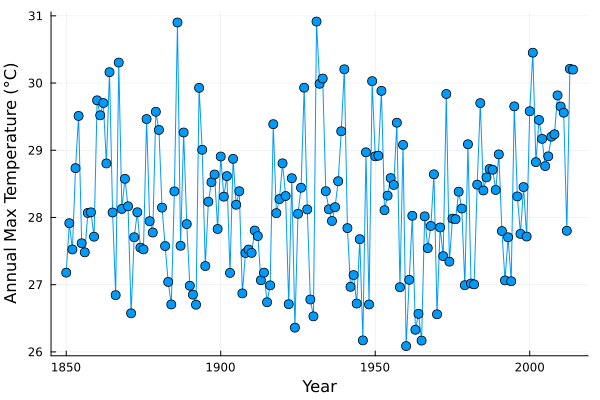

In [60]:
p1 = plot(
    max_dat.Year,
    max_dat.TempMax;
    xlabel="Year",
    ylabel="Annual Max Temperature (°C)",
    label=false,
    marker=:circle,
    markersize=5
)

Fitting GEV

In [61]:
times = max_dat.Year .- max_dat.Year[1]
init_θ = [1.0, 1.0, 1.0]
lb = [0, 0, -1]
ub = [50, 100, 1.5]
gev_lik(θ) = -sum(logpdf(GeneralizedExtremeValue(θ[1], θ[2], θ[3]), max_dat.TempMax))
θ_mle = Optim.optimize(gev_lik, lb, ub, init_θ).minimizer

3-element Vector{Float64}:
 27.828895474571738
  1.0168352688472988
 -0.21878753182978145

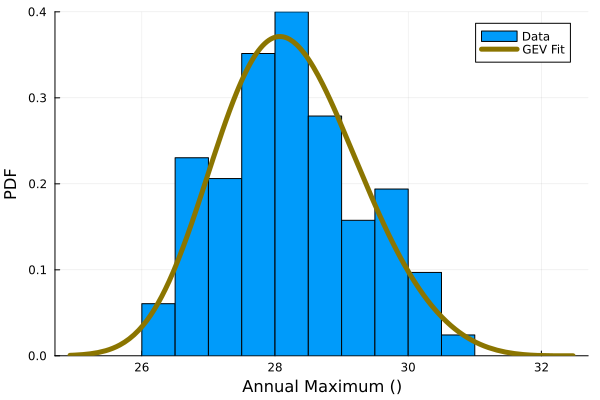

In [62]:
p = histogram(
    max_dat.TempMax,
    normalize=:pdf,
    label="Data",
    xlabel="Annual Maximum ()",
    ylabel="PDF",
    # yticks=[]
)

plot!(GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3]), linewidth=5, label="GEV Fit", color=:gold4)
# xlims!((1, 1.75))
plot!()

In [9]:
rl_100 = quantile(GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3]), 0.99)

30.77773559411247

Location: 27.83

Scale: 1.02

Shape: -0.22

What type of GEV distribution did you end up with? What is
    the 100-year return level?

Since the shape parameter is less than 0, this is a Weibull distribution. The 100-year return level is given to be 30.78 degrees celsius.

In [10]:
-2*(-gev_lik(θ_mle)- length(θ_mle))

492.931019280128

Non-stationary GEV

In [12]:
init_θ = [1.0, 1.0, 1.0,0.0]
lb = [0, 0, 0, -1]
ub = [50, 50,100, 1.5]
gev_lik(θ) = -sum(logpdf.(GeneralizedExtremeValue.(θ[1].+θ[2].*times, θ[3], θ[4]), max_dat.TempMax))
θ_mle = Optim.optimize(gev_lik, lb,ub,init_θ).minimizer

4-element Vector{Float64}:
 27.665923432315385
  0.0020309145049479268
  1.015749098555488
 -0.2212281492475472

In [13]:
-2*(-gev_lik(θ_mle)- length(θ_mle))

493.59147933773136

-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?

AIC for stationary model: 492.93

AIC for nonstationary model: 493.59

The AIC comparison indicates that the models do not lead to significant performance differences. Therefore, more information would be required to assess the evidence for non-stationarity.

### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

I decluster the data based on the code from lecture, using a threshold of 28°C, by first calculating the extremal index and then taking the rounded inverse of this to be the mean time between clusters.

# Solution

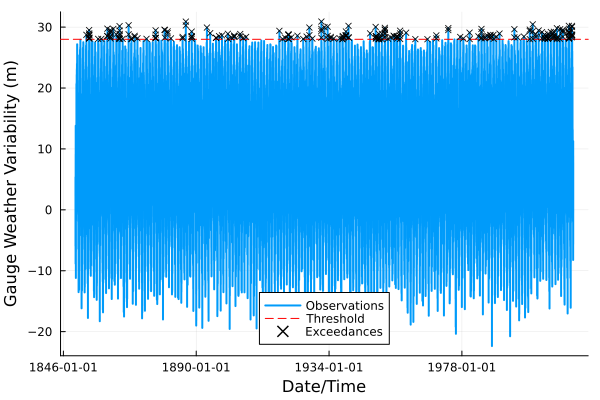

In [ ]:
thresh = 28.0
p1 = plot(ithaca_dat.Day, ithaca_dat.TempMax; linewidth=2, ylabel="Gauge Weather Variability (m)", label="Observations", legend=:bottom, xlabel="Date/Time")
hline!([thresh], color=:red, linestyle=:dash, label="Threshold")
scatter!(ithaca_dat.Day[ithaca_dat.TempMax .> thresh], ithaca_dat.TempMax[ithaca_dat.TempMax .> thresh], markershape=:x, color=:black, markersize=3, label="Exceedances")

In [66]:
# find total number of exceedances and exceedance times
# dat_ma.residual = dat_ma.residual ./ 1000 # convert to m
S = findall(ithaca_dat.TempMax .> thresh)
N = length(S)
T = diff(S) # get difference between adjacent exceedances
θ = 2 * sum(T)^2 / ((N-1) * sum(T.^2)) # extremal index

0.47832378879687915

In [18]:
# cluster data points which occur within period
function assign_cluster(dat, period)
    cluster_index = 1
    clusters = zeros(Int, length(dat))
    for i in 1:length(dat)
        if clusters[i] == 0
            clusters[findall(abs.(dat .- dat[i]) .<= period)] .= cluster_index
            cluster_index += 1
        end
    end
    return clusters
end

# cluster exceedances that occur within a four-hour window
# @transform is a macro from DataFramesMeta.jl which adds a new column based on a data transformation
dat_exceed = ithaca_dat[ithaca_dat.TempMax  .> thresh, :]
dat_exceed = @transform dat_exceed :cluster = assign_cluster(:Day, Dates.Day(round(1/θ)))

Row,Day,TempMax,cluster
,Date,Float64,Int64
1,1853-08-13,28.734,1
2,1854-07-12,29.5106,2
3,1854-07-18,28.131,3
4,1854-07-19,28.9641,3
5,1854-07-31,28.1494,4
6,1854-08-01,28.2747,5
7,1854-08-02,28.6134,5
8,1854-08-03,28.7721,5
9,1857-07-07,28.0677,6


In [20]:
# find maximum value within cluster
dat_decluster = combine(dat_exceed -> dat_exceed[argmax(dat_exceed.TempMax), :], 
    groupby(dat_exceed, :cluster))
dat_decluster

Row,cluster,Day,TempMax
,Int64,Date,Float64
1,1,1853-08-13,28.734
2,2,1854-07-12,29.5106
3,3,1854-07-19,28.9641
4,4,1854-07-31,28.1494
5,5,1854-08-03,28.7721
6,6,1857-07-07,28.0677
7,7,1858-07-29,28.0767
8,8,1860-07-01,28.5655
9,9,1860-07-29,29.743


-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?

In [23]:
dat_decluster -> dat_decluster[length(dat_decluster.cluster), :]

#19 (generic function with 1 method)

In [25]:
clusters_per_year = combine(groupby(transform(dat_decluster, :Day => x->year.(x)), :Day_function), nrow)

Row,Day_function,nrow
,Int64,Int64
1,1853,1
2,1854,4
3,1857,1
4,1858,1
5,1860,3
6,1861,4
7,1862,1
8,1863,1
9,1864,4


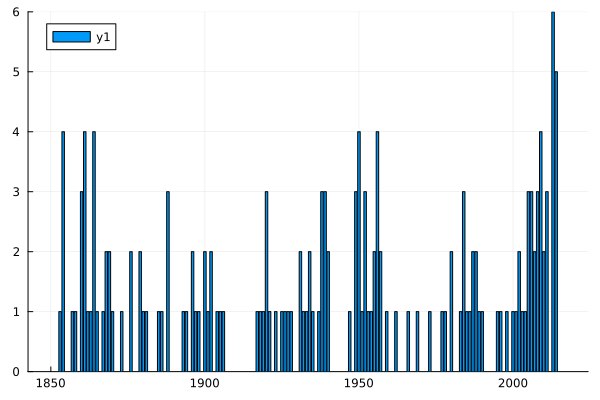

In [26]:
p = bar(clusters_per_year.Day_function, clusters_per_year.nrow)

There does appear to be an increase in the number of exceedances by year. However, it is difficult to tell from just looking at the graph, as this could just be due to a couple of outliers in the last couple years. I can not determine whether there is a trend from only looking at this graph.

-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?

In [71]:
# fit GPD
init_θ = [1.0, 1.0]
low_bds = [0.0, -Inf]
up_bds = [Inf, Inf]
gpd_lik(θ) = -sum(logpdf(GeneralizedPareto(0.0, θ[1], θ[2]), dat_decluster.TempMax .- thresh))
θ_mle = Optim.optimize(θ -> -sum(logpdf(GeneralizedPareto(0.0, θ[1], θ[2]), dat_decluster.TempMax .- thresh)), low_bds, up_bds, init_θ).minimizer



2-element Vector{Float64}:
  0.9025553026698231
 -0.19662265488610028

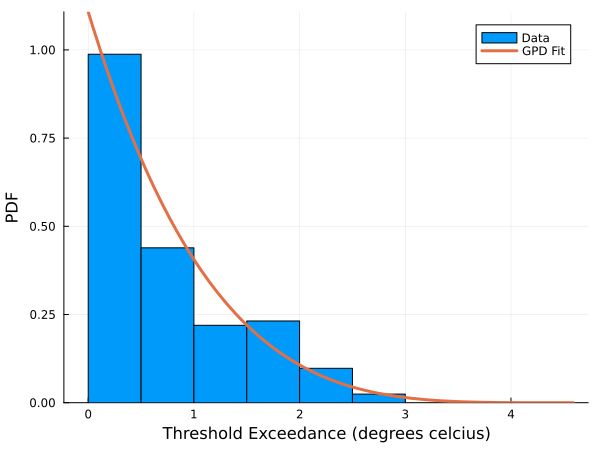

In [34]:
p = histogram(dat_decluster.TempMax .- thresh,
    normalize = :pdf,
    label="Data",
    xlabel="Threshold Exceedance (degrees celcius)",
    ylabel="PDF",
    # yticks=[],
    )
p1 = plot(p, GeneralizedPareto(0.0, θ_mle[1], θ_mle[2]), linewidth=3, label="GPD Fit")
plot!(size=(600, 450))
display(p1)

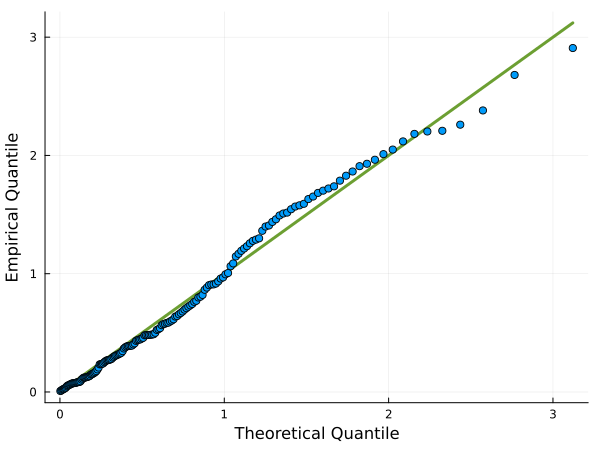

In [35]:

# Q-Q Plot
p2 = qqplot(GeneralizedPareto(0.0, θ_mle[1], θ_mle[2]), dat_decluster.TempMax .- thresh, 
    xlabel="Theoretical Quantile",
    ylabel="Empirical Quantile",
    linewidth=3)
plot!(size=(600, 450))

display(p2)

In [72]:
# add column with years of occurrence
dat_decluster = @transform dat_decluster :year = Dates.year.(dat_decluster.Day)
# group by year and add up occurrences
exceed_counts = combine(groupby(dat_decluster, :year), nrow => :count)
delete!(exceed_counts, nrow(exceed_counts)) # including 2023 will bias the count estimate


Row,year,count
,Int64,Int64
1,1853,1
2,1854,4
3,1857,1
4,1858,1
5,1860,3
6,1861,4
7,1862,1
8,1863,1
9,1864,4


In [ ]:
count_dist = fit(Poisson, exceed_counts.count)
λ = params(count_dist)[1]

1.6914893617021276

In [77]:
# θ_mle[1] = 0.11
# θ_mle[2] = -0.17
# λ = 50
RL = thresh+(θ_mle[1]/θ_mle[2])*((100*λ)^θ_mle[2]-1)

30.91645881217761

-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

The 100-year return level is about 30.9 degrees celsius. This is similar to what was given for the stationary model from problem 1 (30.8). The models are estimating the same quantity, so reasonable agreement between the models is expected. As indicated by the plots above, the threshold for the GPP model is reasonably selected so as not to exclude most extremes. A very high threshold with very little data above it might lead to a deviation in the 100-year return levels between the two models, since the Poisson-GPD model would then not include sufficient data to accurately characterize the distribution above the threshold. Additionally, the distribution of the maximum data is reasonable, without having some years with consistently higher values than others years, which might again lead to deviation between the two models, because the GEV model would then be neglecting a significant number of high values occurring in the same year, since it is only based on annual maxima.


### Problem 3

**This problem is only required for students in BEE 5850**.

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

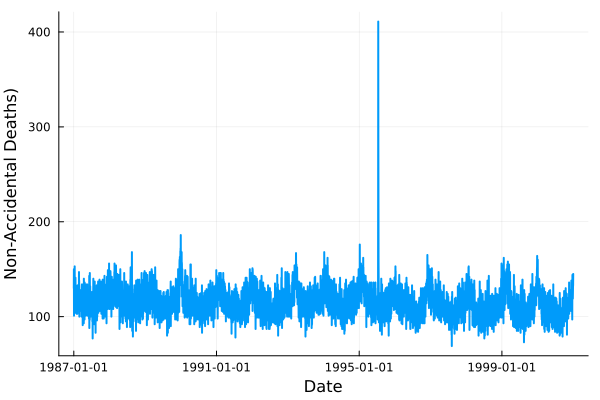

In [41]:
chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)

plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)

**In this problem**:

-   Load and plot the deaths data. Linearly regress the number of deaths
    against time and report the coefficients for the fitted model. Add
    the regression line to your plot. What does this regression tell
    you?
-   Now linearly regress the deaths data against temperature. Once
    again, report the coefficients, and add the regression line to your
    plot. What does this regression tell you about the influence of
    temperature?
-   Expand your previous model by regressing deaths against temperature
    and PM2.5 density. Report the coefficients and add this regression
    line to your plot.
-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

I first drop all data points with missing PM2.5 data from the dataset so that all analysis can be done with the same data, allowing for comparison of AIC values. I use the lm function of the GLM package to fit the models, predict for several values of the predictors in order to generate plots, and return the AIC values for comparison.

# Solution

In [42]:
chicago_dat = chicago_dat[.!(ismissing).(chicago_dat.pm25median),:]

Row,Column1,death,pm10median,pm25median,o3median,so2median,time,tmpd,Date
,Int64,Int64,Float64?,Float64?,Float64,Float64?,Float64,Float64,Date
1,4023,120,-12.619,-6.84961,-15.5012,-2.94688,1465.5,48.0,1998-01-05
2,4029,112,-0.728814,-8.14961,-13.4337,2.99754,1471.5,18.0,1998-01-11
3,4035,127,0.915254,19.7504,-15.5744,0.832351,1477.5,23.0,1998-01-17
4,4041,125,6.46255,15.967,-16.9292,4.24535,1483.5,28.0,1998-01-23
5,4047,110,-1.54237,3.41702,-14.9337,-0.178114,1489.5,37.0,1998-01-29
6,4053,120,-19.2673,-4.44961,7.79579,-4.80075,1495.5,32.0,1998-02-04
7,4059,125,33.8722,11.517,-12.9015,6.30493,1501.5,39.0,1998-02-10
8,4065,129,1.42675,4.56702,-9.71352,0.857845,1507.5,42.0,1998-02-16
9,4071,116,7.62786,9.76702,-5.87954,0.864176,1513.5,44.0,1998-02-22


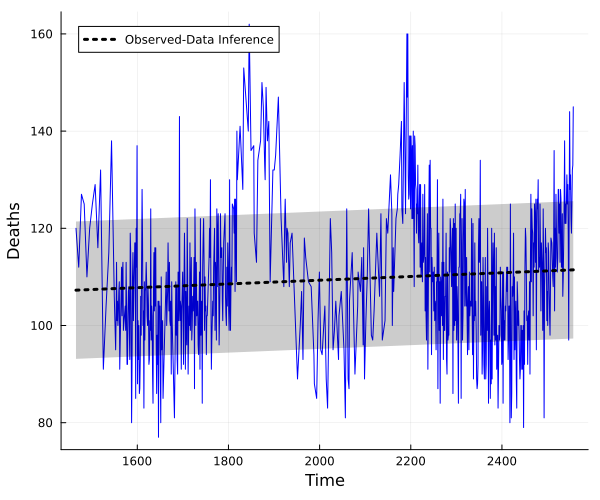

In [78]:
x = chicago_dat.time
y = chicago_dat.death	
n = length(x)
xpred = collect(minimum(x):1:maximum(x))
# lm_all = lm([ones(length(x)) x], y)
# y_lm_all = predict(lm_all, [ones(length(xpred)) xpred])
# missing_y = Bool.(rand(Binomial.(1, 0.25), length(y)))

# missing_y = ismissing.(chicago_dat.death) .|| ismissing.(chicago_dat.tmpd) .|| ismissing.(chicago_dat.pm25median)

# missing_y = ismissing.(chicago_dat.pm25median)
xobs = x
yobs = y

lm_mcar_time = lm([ones(n) xobs], yobs)
y_lm_mcar = predict(lm_mcar_time, [ones(length(xpred)) xpred])


p1 = plot(xobs, yobs, xlabel="Time", ylabel="Deaths", label=false, markersize=5, size=(600, 500), color=:blue)
# scatter!(x[missing_y], y[missing_y], alpha=0.9, color=:lightgrey, label=false, markersize=5)
# plot!(xpred, y_lm_all, color=:red, lw=3, label="Complete-Data Inference", ribbon=GLM.dispersion(lm_all), fillalpha=0.2)
plot!(xpred, y_lm_mcar, color=:black, lw=3, linestyle=:dot, label="Observed-Data Inference", ribbon=GLM.dispersion(lm_mcar_time), fillalpha=0.2)


In [44]:
lm_mcar_time

LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:
─────────────────────────────────────────────────────────────────────────
           Coef.  Std. Error      t  Pr(>|t|)     Lower 95%     Upper 95%
─────────────────────────────────────────────────────────────────────────
x1  101.651       3.3002      30.80    <1e-99  95.1718       108.13
x2    0.00383392  0.00157102   2.44    0.0149   0.000749629    0.00691822
─────────────────────────────────────────────────────────────────────────


Intercept: 101.65

Coefficient: 0.00383

The number of deaths is around constant with time, with a slight increase.

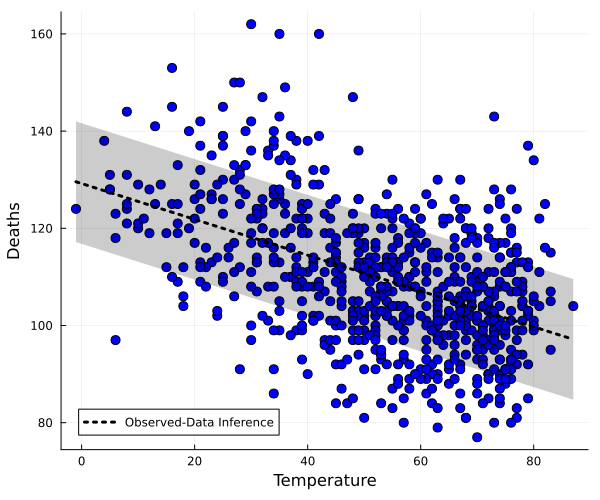

In [79]:
x = chicago_dat.tmpd
y = chicago_dat.death
n = length(x)
xpred = collect(minimum(x):1:maximum(x))
# lm_all = lm([ones(length(x)) x], y)
# y_lm_all = predict(lm_all, [ones(length(xpred)) xpred])
# missing_y = ismissing.(chicago_dat.death) .|| ismissing.(chicago_dat.tmpd)
xobs = x
yobs = y

lm_mcar_tmp = lm([ones(n) xobs], yobs)
y_lm_mcar = predict(lm_mcar_tmp, [ones(length(xpred)) xpred])


p1 = scatter(xobs, yobs, xlabel="Temperature", ylabel="Deaths", label=false, markersize=5, size=(600, 500), color=:blue)
# scatter!(x[missing_y], y[missing_y], alpha=0.9, color=:lightgrey, label=false, markersize=5)
# plot!(xpred, y_lm_all, color=:red, lw=3, label="Complete-Data Inference", ribbon=GLM.dispersion(lm_all), fillalpha=0.2)
plot!(xpred, y_lm_mcar, color=:black, lw=3, linestyle=:dot, label="Observed-Data Inference", ribbon=GLM.dispersion(lm_mcar_tmp), fillalpha=0.2)


In [46]:
lm_mcar_tmp

LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:
────────────────────────────────────────────────────────────────────
         Coef.  Std. Error       t  Pr(>|t|)   Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────
x1  129.209      1.39089     92.90    <1e-99  126.478     131.939
x2   -0.368534   0.0246713  -14.94    <1e-43   -0.416969   -0.320098
────────────────────────────────────────────────────────────────────


Intercept: 129.21

Coefficient: -0.37

The negative coefficient indicates a negative correlation between temperature and deaths. This appears to be much more significant than the relationship to time.

In [47]:
# y_lm_mcar = predict(lm_mcar, [ones(length(xpred)) x1pred x2pred])


# p1 = scatter(xobs, yobs, xlabel="x", ylabel="y", label=false, markersize=5, size=(600, 500), color=:blue)
# # scatter!(x[missing_y], y[missing_y], alpha=0.9, color=:lightgrey, label=false, markersize=5)
# # plot!(xpred, y_lm_all, color=:red, lw=3, label="Complete-Data Inference", ribbon=GLM.dispersion(lm_all), fillalpha=0.2)
# plot!(xpred, y_lm_mcar, color=:black, lw=3, linestyle=:dot, label="Observed-Data Inference", ribbon=GLM.dispersion(lm_mcar), fillalpha=0.2)

In [81]:
x1 = chicago_dat.tmpd 
x2 = chicago_dat.pm25median
y = chicago_dat.death
n = length(x)


# missing_y = ismissing.(chicago_dat.death) .|| ismissing.(chicago_dat.tmpd) .|| ismissing.(chicago_dat.pm25median)
x1obs = x1
x2obs = x2
yobs = y


x1pred = collect(minimum(x1obs):1:maximum(x1obs))
x2pred = collect(minimum(x2obs):1:maximum(x2obs))
x2obs
lm_mcar_tmp_PM = lm([ones(n) x1obs Vector{Float64}[x2obs][1]], yobs)
# y_lm_mcar = predict(lm_mcar_tmp_PM, [ones(length(xpred)) xpred])

LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:
────────────────────────────────────────────────────────────────────
         Coef.  Std. Error       t  Pr(>|t|)   Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────
x1  129.294      1.37612     93.96    <1e-99  126.592     131.996
x2   -0.371118   0.0244148  -15.20    <1e-44   -0.41905    -0.323186
x3    0.215328   0.0525154    4.10    <1e-04    0.112227    0.318428
────────────────────────────────────────────────────────────────────


Intercept: 129.29

Coefficient for Temperature: -0.37

Coefficient for PM2.5: 0.22

The negative coefficient indicates a negative correlation between temperature and deaths. The positive coefficient for PM2.5 indicates positive correlation between PM2.5 and deaths. Both of these seem to be more significant than time.

In [52]:
aic_time = aic(lm_mcar_time)
aic_tmp = aic(lm_mcar_tmp)
aic_tmp_PM = aic(lm_mcar_tmp_PM)

5714.315656401006

In [53]:
aic_time

5918.129872072014

In [54]:
aic_tmp

5729.004547432589

In [55]:
aic_tmp_PM

5714.315656401006

In [56]:
aic_time - aic_tmp

189.12532463942534

In [57]:
aic_tmp - aic_tmp_PM

14.688891031582898

-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

AIC for time regression: 5918.13

AIC for temp regression: 5729.00

AIC for temp and PM2.5 regression: 5714.32



For the first model regressed on time, the high AIC indicating relatively poor predictive performance of this model compared to the model regressed on temperature is an indication that the influence of time is weak. This is consistent with the low coefficient for time. Looking at the data and linear fit, there does not seem to be a significant trend of deaths with time. Therefore, these different pieces of evidence all support a similar conclusion of time having relatively little influence on deaths.

The AIC comparison indicates that the model regressed on temperature performs significantly better than the model regressed on time. Additionally, the addition of the PM2.5 as a predictor leads to improved model skill even when accounting for the added complexity. This indicates that both temperature and PM2.5 density have an impact on the deaths, consistent with suggestions from the regression coefficients and plots. Unlike the plots and regression coefficients, the AIC can also indicate whether inclusion of the variable in a predictive model actually leads to improved predictive performance. Further work would be required in order to establish casualty (for instance, based on a mechanistic understanding of the impacts of PM2.5 concentrations on deaths). 

https://www.jlhub.com/julia/manual/en/function/range